# 🏠 Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts
house prices from features such as area, location, number of rooms, and
age — practicing the full pipeline from data cleaning through to model
interpretation.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Dataset:** a synthetic house-listings dataset (`SquareFeet`, `Bedrooms`,
`Bathrooms`, `Neighborhood`, `YearBuilt` → `Price`), built to match the
schema and typical statistical shape of Kaggle's popular **"Housing Price
Prediction Data"** dataset (search *"house price prediction dataset"* on
Kaggle) — one of the two datasets this task's self-sourcing guideline
points to alongside the larger, 79-feature Ames Housing dataset.

> **Note on the data source:** the full Ames Housing / Kaggle "House
> Prices: Advanced Regression Techniques" dataset (1,460 rows × 81
> columns) requires a Kaggle account/API download and is a lot of
> dataset for a *basic* project. This notebook instead uses a
> right-sized, generated dataset in the same **area / location / rooms /
> age → price** shape, with a small, seeded amount of realistic messiness
> (missing values, inconsistent category casing, a few duplicate rows)
> added on top so the cleaning section has genuine work to do. **To use
> real data instead:** download the Kaggle dataset (either one) and drop
> it in `data/`, then adjust the column names in Section 2 to match — the
> rest of the pipeline (cleaning → EDA → encoding → modeling → evaluation)
> works the same way regardless of the exact source.

**Notebook structure**
1. Load & inspect data
2. Feature selection discussion
3. Data cleaning
4. EDA
5. Feature engineering (`Age`) & encoding
6. Correlation heatmap
7. Train/test split
8. Train Linear Regression
9. Evaluate (MSE, RMSE, R²)
10. Actual vs. predicted scatter plot
11. Residual plot
12. Coefficient analysis
13. Bonus: Ridge & Lasso comparison
14. Conclusion


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 2. Load the Dataset & Initial EDA

We load the raw CSV, check its shape and dtypes, count nulls, and look at
descriptive statistics and the distribution of the target variable
(`Price`) before doing anything else.


In [2]:
RAW_PATH = "../data/house_data_raw.csv"

df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 1204 rows, 6 columns


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,1710.0,2.0,1.0,Suburb,2016.0,266300
1,3210.0,5.0,4.0,Urban,2002.0,564200
2,2122.0,3.0,3.0,Suburb,2001.0,310500
3,2679.0,3.0,3.0,Rural,2001.0,387100
4,2335.0,3.0,2.0,Urban,1981.0,408500


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1204 entries, 0 to 1203
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    1202 non-null   float64
 1   Bedrooms      1203 non-null   float64
 2   Bathrooms     1203 non-null   float64
 3   Neighborhood  1202 non-null   str    
 4   YearBuilt     1203 non-null   float64
 5   Price         1204 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 56.6 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values per column:
SquareFeet      2
Bedrooms        1
Bathrooms       1
Neighborhood    2
YearBuilt       1
Price           0
dtype: int64

Total missing cells: 7


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SquareFeet,1202.0,NaN,NaN,NaN,2459.288686,1011.76168,655.0,1595.5,2481.0,3327.0,4198.0
Bedrooms,1203.0,NaN,NaN,NaN,3.74813,1.606632,1.0,2.0,4.0,5.0,6.0
Bathrooms,1203.0,NaN,NaN,NaN,2.837905,1.25507,1.0,2.0,3.0,4.0,5.0
Neighborhood,1202,11,Suburb,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YearBuilt,1203.0,NaN,NaN,NaN,1985.554447,20.168574,1950.0,1968.0,1987.0,2003.0,2021.0
Price,1204.0,NaN,NaN,NaN,388073.754153,149492.392683,78900.0,264375.0,391650.0,513800.0,692900.0


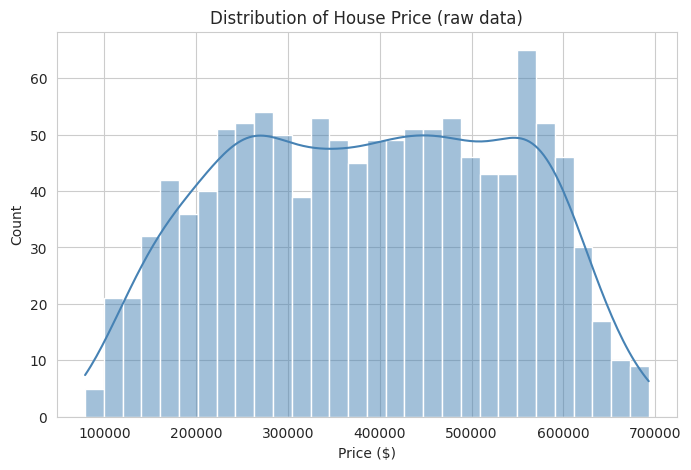

count      1204.000000
mean     388073.754153
std      149492.392683
min       78900.000000
25%      264375.000000
50%      391650.000000
75%      513800.000000
max      692900.000000
Name: Price, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Price (raw data)")
plt.xlabel("Price ($)")
plt.show()

print(df["Price"].describe())


## 3. Feature Selection Discussion

Before touching the model, it's worth reasoning about which columns are
likely to actually predict price, and why:

- **`SquareFeet` (area)** — almost always the single strongest predictor of
  house price: bigger homes cost more to build and offer more usable
  space. We'd expect a strong *positive* correlation with `Price`.
- **`Bedrooms` / `Bathrooms` (rooms)** — proxies for both size and
  livability. They tend to correlate with `SquareFeet` too (more rooms
  usually means more area), so their *combined* effect with area is worth
  watching for multicollinearity once we get to coefficient analysis.
- **`Neighborhood` (location)** — the classic "location, location,
  location" factor. Even holding size constant, an urban property
  typically commands a premium over a rural one due to demand, amenities,
  and access to jobs/transit. This is categorical, so it needs encoding.
- **`YearBuilt` → `Age`** — older homes can be cheaper (dated systems,
  more deferred maintenance) or, in some markets, *more* expensive
  (character, established neighborhoods) — the direction isn't obvious a
  priori, which is exactly why we let the model estimate it rather than
  assuming.

We do **not** expect a raw row identifier or purely administrative fields
to carry predictive signal, so none are included in this dataset to begin
with. All five remaining columns are kept as candidate features.


## 4. Data Cleaning

Handle nulls, encode-ready the categorical text, and remove duplicates.


### 4.1 Null values

In [7]:
# Drop rows missing the target -- can't train/evaluate on those
df = df.dropna(subset=["Price"])

# Numeric columns: impute with the median (robust to outliers)
numeric_cols = ["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled {col} nulls with median = {median_val}")

# Categorical columns: impute with the mode (most frequent category)
if df["Neighborhood"].isnull().any():
    mode_val = df["Neighborhood"].mode()[0]
    df["Neighborhood"] = df["Neighborhood"].fillna(mode_val)
    print(f"Filled Neighborhood nulls with mode = {mode_val}")

print(f"\nRemaining missing cells: {df.isnull().sum().sum()}")


Filled SquareFeet nulls with median = 2481.0
Filled Bedrooms nulls with median = 4.0
Filled Bathrooms nulls with median = 3.0
Filled YearBuilt nulls with median = 1987.0


Filled Neighborhood nulls with mode = Suburb

Remaining missing cells: 0


### 4.2 Duplicate rows

In [8]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 4
Shape after removing duplicates: (1200, 6)


### 4.3 Inconsistent categorical values

In [9]:
print("Neighborhood values before standardizing:", sorted(df["Neighborhood"].unique()))

df["Neighborhood"] = df["Neighborhood"].astype(str).str.strip().str.title()

print("Neighborhood values after standardizing: ", sorted(df["Neighborhood"].unique()))


Neighborhood values before standardizing: [' Urban', 'RURAL', 'Rural', 'SUBURB', 'Suburb', 'Suburb ', 'URBAN', 'Urban', 'rural', 'suburb', 'urban']
Neighborhood values after standardizing:  ['Rural', 'Suburb', 'Urban']


In [10]:
# A couple of numeric sanity checks
for col in numeric_cols:
    df[col] = df[col].astype(int)

assert (df["Price"] > 0).all(), "Found non-positive price!"
assert (df["YearBuilt"] > 1800).all(), "Found an implausible year built!"
print("Sanity checks passed. Clean dataset shape:", df.shape)


Sanity checks passed. Clean dataset shape: (1200, 6)


## 5. Feature Engineering: `Age`

In [11]:
CURRENT_YEAR = 2024
df["Age"] = CURRENT_YEAR - df["YearBuilt"]

df[["YearBuilt", "Age"]].sample(5, random_state=1)


,YearBuilt,Age
636,1960,64
683,1965,59
1033,2013,11
190,1983,41
1083,1985,39


## 6. More EDA (post-cleaning)

/tmp/ipykernel_100/3771579055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Neighborhood", y="Price", ax=axes[1], palette="Set2")


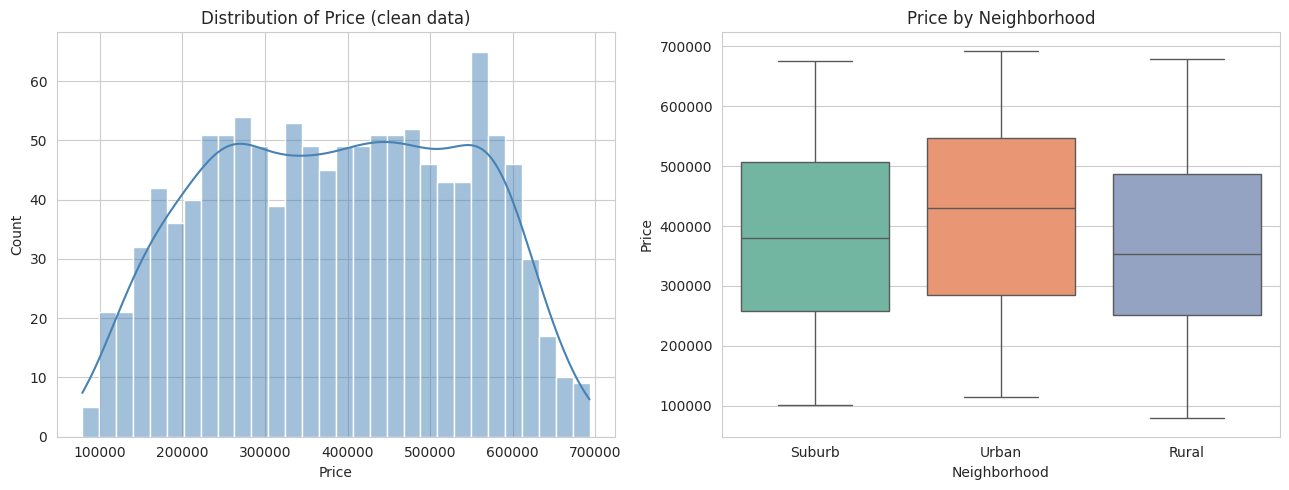

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Price (clean data)")

sns.boxplot(data=df, x="Neighborhood", y="Price", ax=axes[1], palette="Set2")
axes[1].set_title("Price by Neighborhood")

plt.tight_layout()
plt.show()


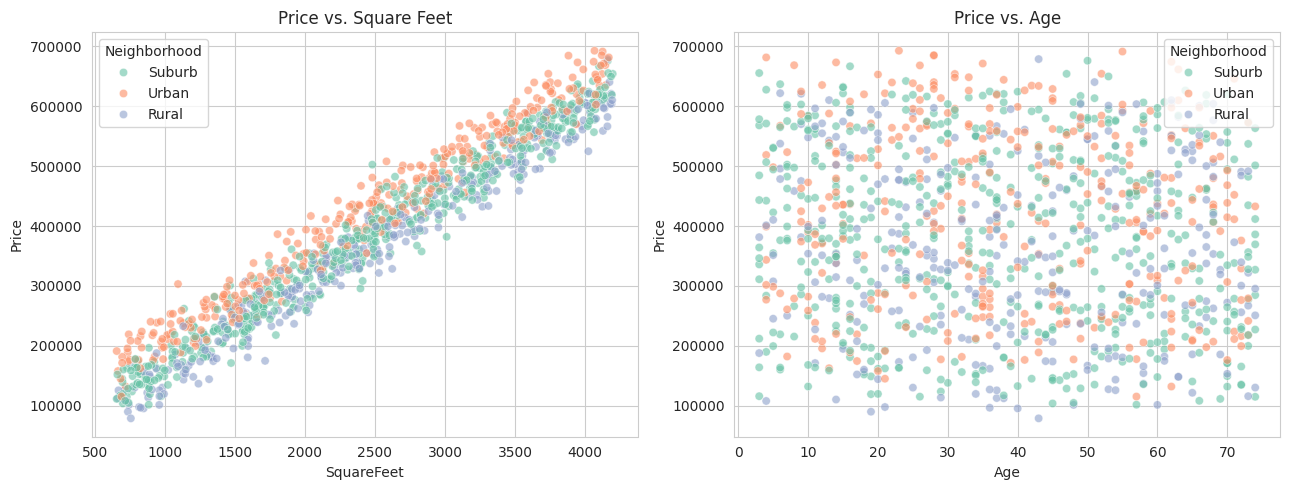

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="SquareFeet", y="Price", hue="Neighborhood",
                 alpha=0.6, ax=axes[0], palette="Set2")
axes[0].set_title("Price vs. Square Feet")

sns.scatterplot(data=df, x="Age", y="Price", hue="Neighborhood",
                 alpha=0.6, ax=axes[1], palette="Set2")
axes[1].set_title("Price vs. Age")

plt.tight_layout()
plt.show()


/tmp/ipykernel_100/2868914841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Bedrooms", y="Price", palette="Set3")


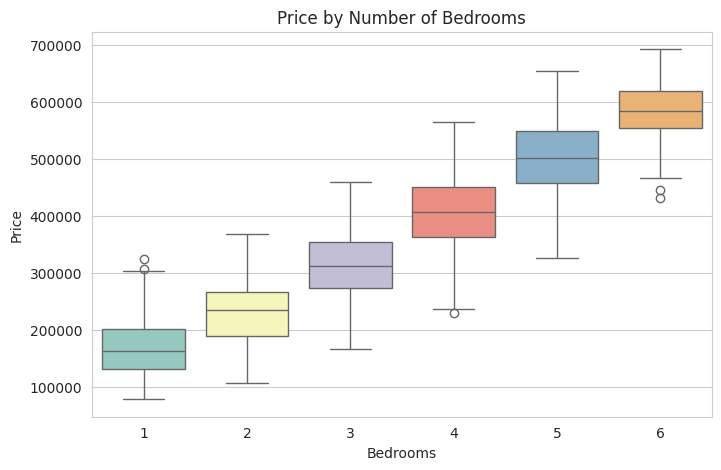

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Bedrooms", y="Price", palette="Set3")
plt.title("Price by Number of Bedrooms")
plt.show()


## 7. Encode Categorical Features

One-Hot Encode `Neighborhood` (drop first level to avoid the dummy-variable
trap for linear models), then drop the now-redundant `YearBuilt` (replaced
by `Age`).


In [15]:
model_df = df.drop(columns=["YearBuilt"])
model_df = pd.get_dummies(model_df, columns=["Neighborhood"], drop_first=True)

print(f"Shape after encoding: {model_df.shape}")
model_df.head()


Shape after encoding: (1200, 7)


,SquareFeet,Bedrooms,Bathrooms,Price,Age,Neighborhood_Suburb,Neighborhood_Urban
0,1710,2,1,266300,8,True,False
1,3210,5,4,564200,22,False,True
2,2122,3,3,310500,23,True,False
3,2679,3,3,387100,23,False,False
4,2335,3,2,408500,43,False,True


## 8. Feature Correlation Heatmap

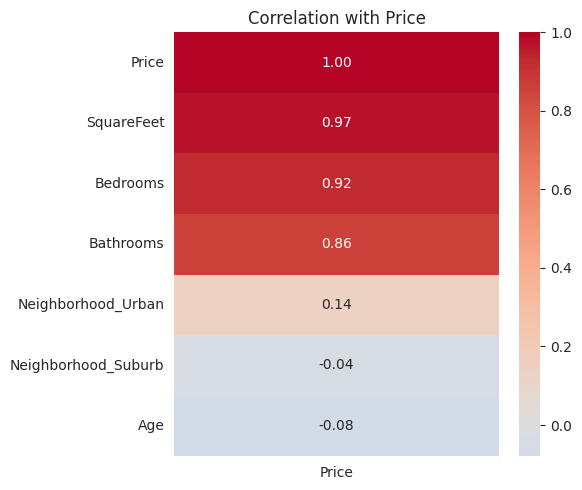

In [16]:
plt.figure(figsize=(6, 5))
corr = model_df.corr(numeric_only=True)

sns.heatmap(corr[["Price"]].sort_values("Price", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with Price")
plt.tight_layout()
plt.show()


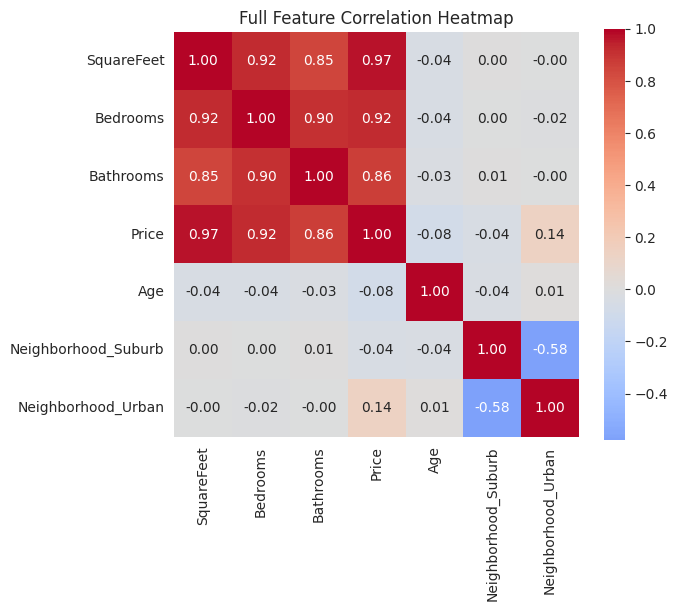

In [17]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Full Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 9. Train / Test Split (80/20)

In [18]:
X = model_df.drop(columns=["Price"])
y = model_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Number of features: {X_train.shape[1]}")


Train set: 960 rows | Test set: 240 rows
Number of features: 6


## 10. Train the Linear Regression Model

In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
print("Model trained.")


Model trained.


## 11. Evaluate the Model — MSE, RMSE, R²

In [20]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")


MSE:  496,877,475.34
RMSE: 22,290.75
R2:   0.9766


## 12. Actual vs. Predicted Prices

Points closer to the diagonal (`y = x`) line indicate more accurate
predictions.


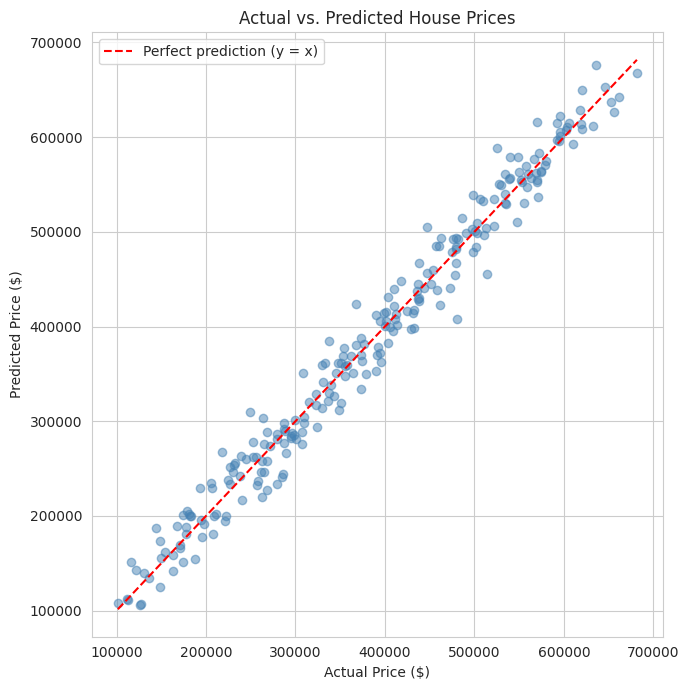

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Residual Plot

Residuals (actual − predicted) should scatter randomly around zero with no
obvious pattern. A visible curve or funnel shape would suggest the model
is missing a non-linear relationship or has unequal error variance
(heteroscedasticity).


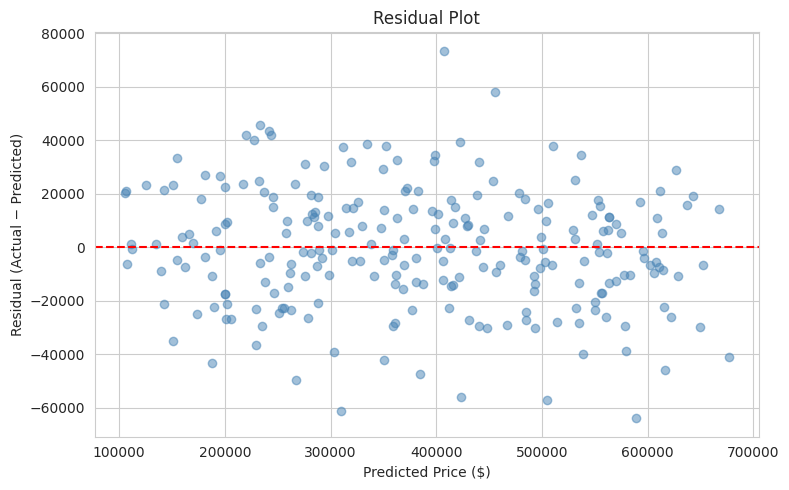

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


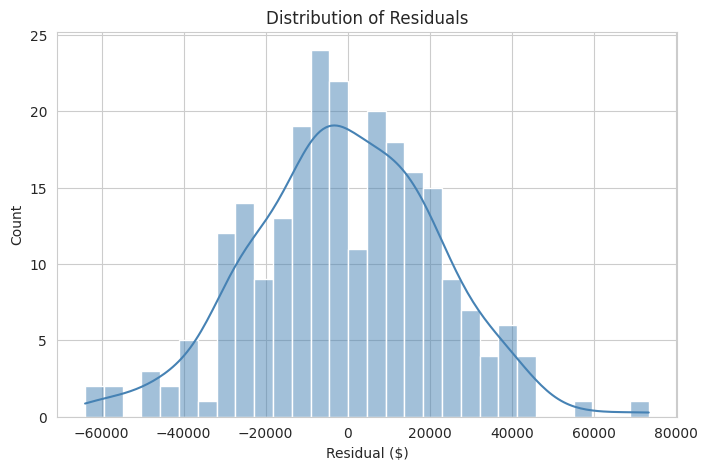

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="steelblue")
plt.title("Distribution of Residuals")
plt.xlabel("Residual ($)")
plt.show()


## 14. Coefficient Analysis

Which features push price up, and which push it down? Since all features
here are on meaningfully different scales, we standardize a copy of the
inputs before refitting so the coefficient *magnitudes* are directly
comparable to each other.


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Raw Coefficient": lin_reg.coef_,
    "Standardized Coefficient": lin_reg_scaled.coef_,
}).sort_values("Standardized Coefficient", key=abs, ascending=False)

coef_df


,Feature,Raw Coefficient,Standardized Coefficient
0,SquareFeet,119.569110,121571.539431
5,Neighborhood_Urban,57508.895953,25943.196742
2,Bathrooms,13907.587521,17396.046068
1,Bedrooms,6918.453254,11135.530793
4,Neighborhood_Suburb,17234.604423,8582.654885
3,Age,-283.861646,-5686.829896


/tmp/ipykernel_100/773178943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Standardized Coefficient", y="Feature", palette=colors.tolist())


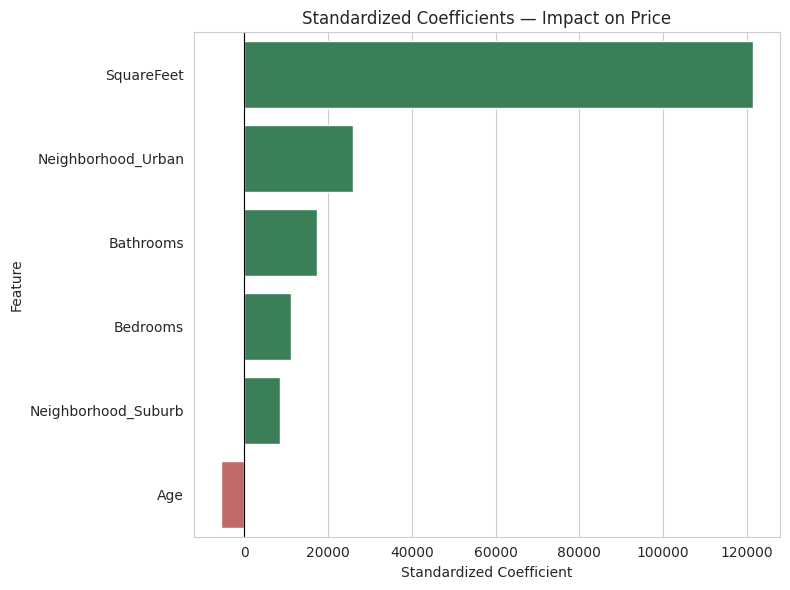

In [25]:
plt.figure(figsize=(8, 6))
colors = coef_df["Standardized Coefficient"].apply(lambda v: "seagreen" if v > 0 else "indianred")
sns.barplot(data=coef_df, x="Standardized Coefficient", y="Feature", palette=colors.tolist())
plt.title("Standardized Coefficients — Impact on Price")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**Reading the chart:** positive bars push price up, negative bars pull it
down, and longer bars matter more (in standard-deviation terms) once every
feature is put on the same scale. `SquareFeet` is typically the dominant
driver, `Neighborhood_Urban` a strong positive push relative to the
dropped baseline category, and `Age` a modest negative one.


## 15. Bonus: Ridge & Lasso Regularized Models

Ridge (L2) shrinks coefficients smoothly; Lasso (L1) can shrink some
coefficients all the way to zero, effectively doing feature selection.
We compare both against plain Linear Regression on the same test set.


In [26]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
lasso = Lasso(alpha=1.0, random_state=RANDOM_STATE)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

reg_results = []
for name, model in [("Linear Regression", lin_reg), ("Ridge", ridge), ("Lasso", lasso)]:
    preds = model.predict(X_test)
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2 Score": r2_score(y_test, preds),
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
reg_results_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,17686.242411,22290.748649,0.976573
1,Lasso,17686.432727,22290.915309,0.976573
2,Ridge,17697.568532,22301.012094,0.976552


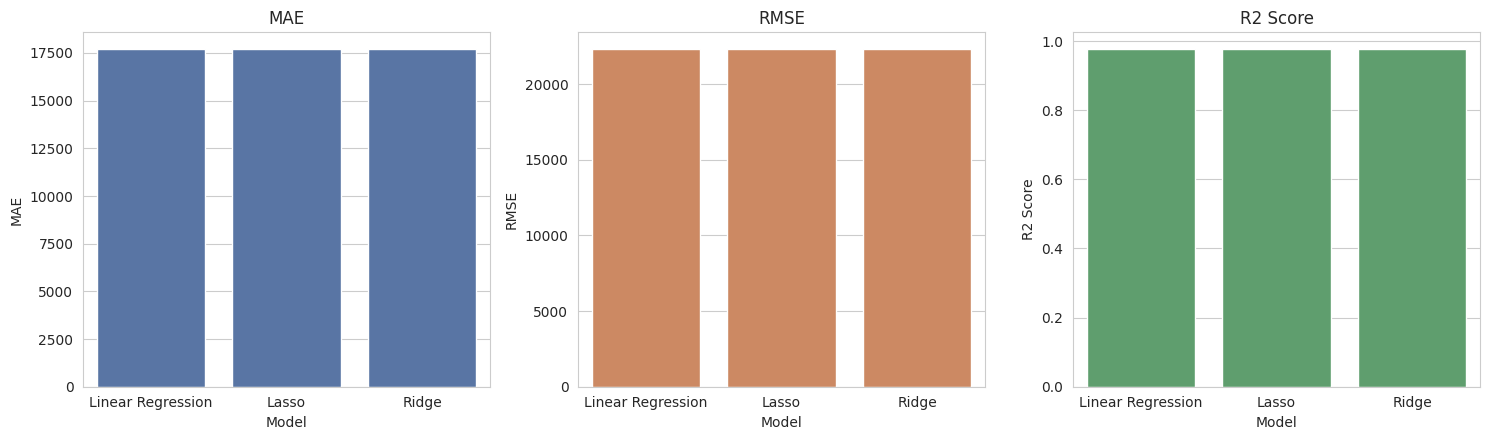

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["MAE", "RMSE", "R2 Score"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=reg_results_df, x="Model", y=metric, ax=ax, color=color)
    ax.set_title(metric)

plt.tight_layout()
plt.show()


## 16. Conclusion

- The dataset was cleaned (nulls imputed, duplicates removed, categorical
  text standardized) and enriched with an **`Age`** feature derived from
  `YearBuilt`.
- **`SquareFeet`** is the dominant predictor of price, with `Neighborhood`
  (location) and room counts contributing meaningfully; `Age` has a
  smaller, generally negative effect in this dataset.
- The residual plot shows errors scattered fairly evenly around zero with
  no strong pattern, suggesting a linear model is a reasonable fit for
  this data — though real-world housing data often has more curvature
  (e.g. diminishing returns on extra square footage) that a plain linear
  model would miss.
- Ridge and Lasso perform similarly to plain Linear Regression here since
  the feature set is small and not strongly collinear; regularization
  tends to matter more with many correlated features (as in the full
  79-feature Ames dataset).
- **Next steps** you could try: swap in the real Kaggle dataset for a
  richer feature set, engineer interaction terms (e.g. `SquareFeet ×
  Neighborhood`), try polynomial features for non-linear relationships,
  and tune `alpha` for Ridge/Lasso with `GridSearchCV`.
